In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

INPUT_FILE = "dataset/FAOSTAT_data_en_11-1-2024.csv"
OUTPUT_FILE = "Thailand_Temperature_Clean.csv"



In [2]:

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    encoding="latin1"
)

print("=" * 70)
print("ORIGINAL DATA")
print("=" * 70)

print("Shape:", df.shape)
print(df.columns.tolist())


ORIGINAL DATA
Shape: (241893, 14)
['ï»¿Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Months Code', 'Months', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description']


In [3]:

# ============================================================
# 2. CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

print("\nColumns:")
print(df.columns.tolist())



Columns:
['ï»¿Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Months Code', 'Months', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description']


In [4]:

# ============================================================
# 3. SELECT THAILAND
# ============================================================

df = df[
    df["Area"].astype(str).str.strip() == "Thailand"
].copy()

print("\nThailand rows:", len(df))


Thailand rows: 1071


In [5]:

# ============================================================
# 4. SELECT TEMPERATURE CHANGE
# ============================================================

df = df[
    df["Element"].astype(str).str.strip()
    == "Temperature change"
].copy()


In [6]:

# ============================================================
# 5. SELECT ANNUAL DATA
# ============================================================

df = df[
    df["Months"].astype(str).str.strip()
    == "Meteorological year"
].copy()

In [7]:

# ============================================================
# 6. SELECT ONLY REQUIRED COLUMNS
# ============================================================

df = df[
    [
        "Area",
        "Year",
        "Unit",
        "Value",
        "Flag"
    ]
].copy()

In [8]:

# ============================================================
# 7. CONVERT DATA TYPE
# ============================================================

df["Year"] = pd.to_numeric(
    df["Year"],
    errors="coerce"
)

df["Value"] = pd.to_numeric(
    df["Value"],
    errors="coerce"
)


In [9]:

# ============================================================
# 8. REMOVE MISSING VALUES
# ============================================================

print("\nMissing values:")
print(df.isnull().sum())

df = df.dropna(
    subset=["Year", "Value"]
)


Missing values:
Area     0
Year     0
Unit     0
Value    0
Flag     0
dtype: int64


In [10]:

# ============================================================
# 9. REMOVE DUPLICATES
# ============================================================

duplicates = df.duplicated().sum()

print("\nDuplicate rows:", duplicates)

df = df.drop_duplicates()




Duplicate rows: 0


In [11]:
# ============================================================
# 10. SORT BY YEAR
# ============================================================

df = df.sort_values(
    "Year"
).reset_index(drop=True)



In [12]:

# ============================================================
# 11. CHECK DUPLICATE YEARS
# ============================================================

duplicate_years = (
    df["Year"].duplicated().sum()
)

print(
    "Duplicate years:",
    duplicate_years
)


Duplicate years: 0


In [13]:
# ============================================================
# 12. CHECK MISSING YEARS
# ============================================================

min_year = int(df["Year"].min())
max_year = int(df["Year"].max())

expected_years = set(
    range(min_year, max_year + 1)
)

actual_years = set(
    df["Year"].astype(int)
)

missing_years = sorted(
    expected_years - actual_years
)

print("\nYear range:")
print(min_year, "-", max_year)

print(
    "Missing years:",
    missing_years
)


Year range:
1961 - 2023
Missing years: []


In [14]:

# ============================================================
# 13. IF MISSING YEAR → INTERPOLATE
# ============================================================

if len(missing_years) > 0:

    full_years = pd.DataFrame({
        "Year": range(
            min_year,
            max_year + 1
        )
    })

    df = full_years.merge(
        df,
        on="Year",
        how="left"
    )

    df["Value"] = (
        df["Value"]
        .interpolate(
            method="linear"
        )
    )

In [15]:
# ============================================================
# 14. FINAL DATA CLEAN
# ============================================================

df = df[
    ["Year", "Value"]
].copy()

df = df.sort_values(
    "Year"
).reset_index(drop=True)


In [16]:

# ============================================================
# 15. CHECK FINAL DATA
# ============================================================

print("\n" + "=" * 70)
print("CLEAN DATA")
print("=" * 70)

print(df.to_string(index=False))


print("\nStatistics:")
print(df["Value"].describe())


CLEAN DATA
 Year  Value
 1961 -0.165
 1962 -0.158
 1963 -0.328
 1964 -0.038
 1965 -0.238
 1966  0.399
 1967 -0.056
 1968 -0.131
 1969  0.454
 1970 -0.005
 1971 -0.491
 1972  0.028
 1973  0.353
 1974 -0.467
 1975  0.095
 1976 -0.516
 1977  0.088
 1978  0.279
 1979  0.590
 1980  0.497
 1981  0.305
 1982  0.140
 1983  0.444
 1984  0.104
 1985  0.300
 1986  0.088
 1987  0.763
 1988  0.271
 1989  0.299
 1990  0.513
 1991  0.641
 1992  0.358
 1993  0.294
 1994  0.353
 1995  0.681
 1996  0.228
 1997  0.388
 1998  1.424
 1999  0.409
 2000  0.042
 2001  0.628
 2002  0.631
 2003  0.771
 2004  0.515
 2005  0.859
 2006  0.652
 2007  0.523
 2008  0.378
 2009  0.493
 2010  1.293
 2011  0.247
 2012  0.908
 2013  1.109
 2014  0.692
 2015  1.202
 2016  1.462
 2017  1.044
 2018  0.813
 2019  1.714
 2020  1.475
 2021  1.012
 2022  0.937
 2023  1.447

Statistics:
count    63.000000
mean      0.460952
std       0.507697
min      -0.516000
25%       0.099500
50%       0.399000
75%       0.727500
max       

In [17]:

# ============================================================
# 16. FIND LATEST YEAR
# ============================================================

latest_year = int(
    df["Year"].max()
)

print("\nLatest year:", latest_year)



Latest year: 2023


In [18]:

# ============================================================
# 17. FORECAST YEARS
# ============================================================

future_years = np.arange(
    latest_year + 1,
    latest_year + 6
)

print("\nForecast years:")

for year in future_years:
    print(year)


Forecast years:
2024
2025
2026
2027
2028


In [19]:
# ============================================================
# 18. SAVE CLEAN DATA
# ============================================================

df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved:", OUTPUT_FILE)




Saved: Thailand_Temperature_Clean.csv


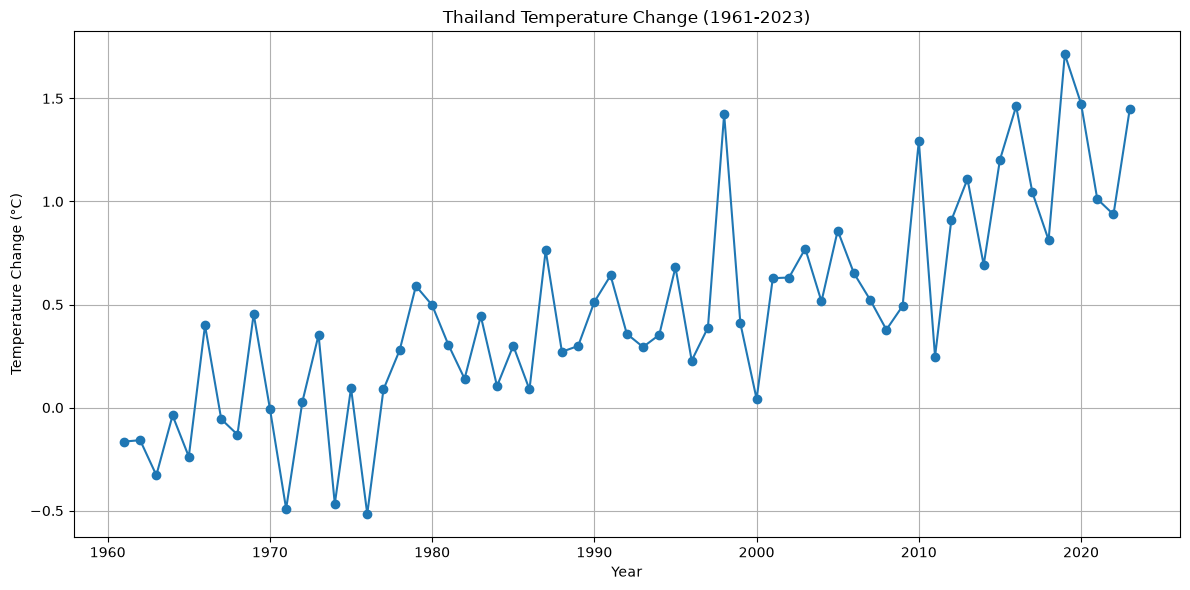

In [20]:

# ============================================================
# 19. PLOT CLEAN DATA
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    df["Year"],
    df["Value"],
    marker="o"
)

plt.title(
    "Thailand Temperature Change (1961-2023)"
)

plt.xlabel("Year")

plt.ylabel(
    "Temperature Change (°C)"
)

plt.grid(True)

plt.tight_layout()

plt.show()